# Impact of AI on students academic performance — Exploratory Data Analysis
The aim of this project is to analyse the impact that Artificial Intelligence has had on the progress of university students, and answer the research question of, 'Is there a correlation between AI and academic improvement or decline?'

**Research question 1:** Does AI usage influence academic decline or improvement? And how significant is its impact

**Research question 2:** Does AI dependency engender burnout, and academic anxiety?

**Hypothesis:** If AI usage has an impact on academic anxiety, then it is the leading cause for academic burnout.

## 1. Importing libraries and loading data

Importing the necessary libraries for the Exploratory data analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

df = pd.read_excel("./ai_student_impact_dataset.xlsx")

## 2. Dataset overview
This is to get a feel, understanding, of the data that we are dealing

In [2]:
df.head(10)

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium
5,100006,STEM,Junior,3.449,6.50,Debugging/Troubleshooting,Beginner,1,False,14.19,4,Allowed_With_Citation,5,3.666,65.92,High
6,100007,STEM,Freshman,3.622,31.41,Summarizing_Reading,Advanced,5,True,13.11,8,Allowed_With_Citation,7,4.000,67.97,Medium
7,100008,Arts,Junior,2.746,5.33,Copywriting/Drafting,Intermediate,3,False,18.45,2,Actively_Encouraged,1,2.965,85.09,Medium
8,100009,Business,Sophomore,3.420,2.00,Debugging/Troubleshooting,Beginner,2,True,2.87,1,Strict_Ban,5,3.396,55.71,Medium
9,100010,Business,Sophomore,3.046,19.99,Debugging/Troubleshooting,Intermediate,2,True,12.49,3,Strict_Ban,8,2.978,87.18,High


In [3]:
print(f"Dataframe contains {df.shape[0]} rows and {df.shape[1]} columns\n")
print(f"{df.isnull().sum()}\n")
print(f"{df.info()}\n")
print("The dataset doesn't have any null values so we can jump straight to visualisations, in order to understand distributions and whether we have outliers, because a dataset having no missing values is not a direct indication of it being absolved of outliers.")

Dataframe contains 50000 rows and 16 columns

Student_ID                    0
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  str    
 2   Year_of_Study               50000 non-null  str    
 3   Pre_Semester_GPA            50000 non-nu

## 3. Visualising the distributions for semester GPAs
The below visualisation analyses the distribution of `pre-semester` and `post-semester gpas`, to ascertain whether there have been major differences from the start, during the academic year and after the end of the semester. And if these changes, if any, were negative or positive.

In [49]:
df[[cols[0], cols[1]]].describe()

,Pre_Semester_GPA,Post_Semester_GPA
count,50000.000000,50000.000000
mean,3.146102,3.349299
std,0.478854,0.495673
min,1.183000,1.000000
25%,2.834000,3.023750
50%,3.210000,3.421000
75%,3.521000,3.749000
max,3.998000,4.000000


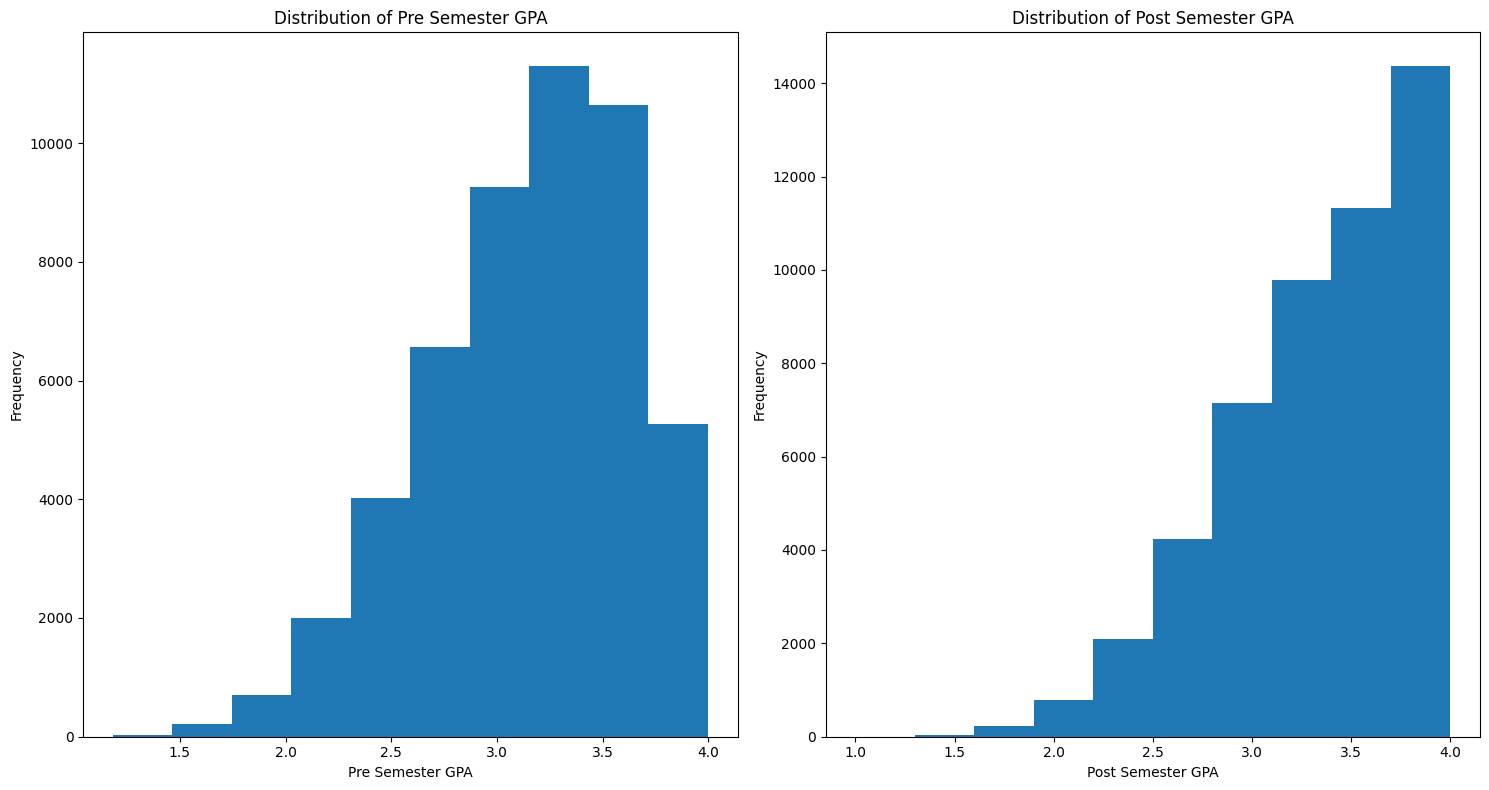

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

#Columns whose distribution we're looking at
cols = ["Pre_Semester_GPA","Post_Semester_GPA"]

#first visual
axes[0].hist(df[cols[0]])
axes[0].set_title("Distribution of Pre Semester GPA")
axes[0].set_xlabel("Pre Semester GPA")
axes[0].set_ylabel("Frequency")

#second visual
axes[1].hist(df[cols[1]])
axes[1].set_title("Distribution of Post Semester GPA")
axes[1].set_xlabel("Post Semester GPA")
axes[1].set_ylabel("Frequency")

#Showing visualisations
plt.tight_layout()
plt.show()

The distribution shows that the data has a negative distribution and a left skew. This suggests that the median is greater than the mean, furthermore, pre semester gpas seemed to have been heading toward a normal distribution suggesting that the mean and median were moving toward  being equal.

In [64]:
#Finding the percentage differences in Pre and Post semester GPAs and computing the growth.
pre_mean = df["Pre_Semester_GPA"].mean()
post_mean = df["Post_Semester_GPA"].mean()

GPA_growth_pct = ((post_mean - pre_mean) / pre_mean) * 100
GPA_growth_pct

print(f"Pre-Semester mean GPA: {pre_mean.round(2)}")
print(f"Post-Semester mean GPA: {post_mean.round(2)}")
print(f"Overall growth in mean GPA: {GPA_growth_pct.round(2)}%")


Pre-Semester mean GPA: 3.15
Post-Semester mean GPA: 3.35
Overall growth in mean GPA: 6.46%


In [20]:
#Computing whether AI Weekly Use has an impact on the Post Semester GPA
corr_ai_gpa = df["Weekly_GenAI_Hours"].corr(df["Post_Semester_GPA"])
print(f"There seems to be a negative relationship between AI usage and the Post Semester GPA, as suggested by the coefficient of {corr_ai_gpa.round(2)}")

There seems to be a negative relationship between AI usage and the Post Semester GPA, as suggested by the coefficient of -0.02


## 5. Visualising the summary statistics of the AI usage per week for every level of the students.

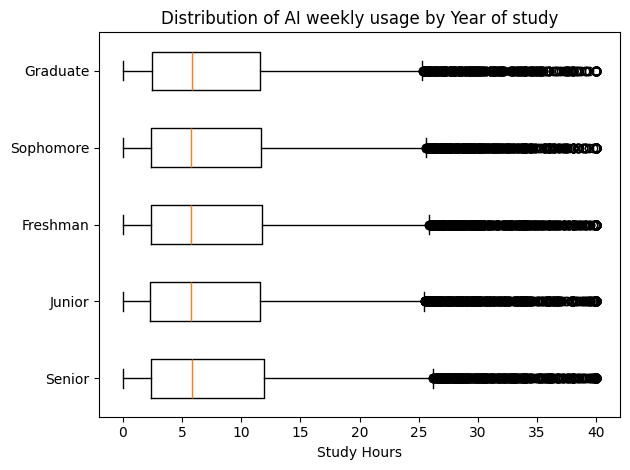

In [33]:
fig, ax = plt.subplots()

year_study = df["Year_of_Study"].unique()
week_hour = [df[df["Year_of_Study"] == labels]["Weekly_GenAI_Hours"] for labels in year_study]

ax.boxplot(week_hour, tick_labels=year_study, vert=False)
ax.set_title("Distribution of AI weekly usage by Year of study")
ax.set_xlabel("Study Hours")

plt.tight_layout()
plt.show()

## 6. Boxplot of the prompt engineering skill against traditional study hours

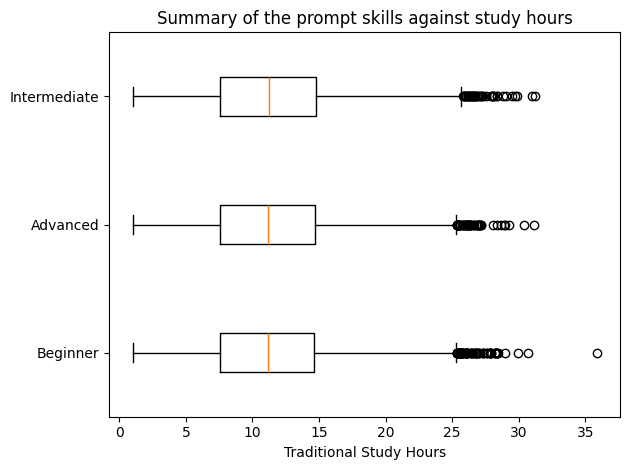

In [26]:
fig, ax = plt.subplots()

Skills = df["Prompt_Engineering_Skill"].unique()
data = [df[df["Prompt_Engineering_Skill"] == skill]["Traditional_Study_Hours"] for skill in Skills]

ax.boxplot(data, tick_labels=Skills, vert=False)
ax.set_title("Summary of the prompt skills against study hours")
ax.set_xlabel("Traditional Study Hours")

plt.tight_layout()
plt.show()

## 7. Visualising skill retention abilities by major category with AI weekly usage
AI weekly use  by students from different majors and how it affects their skill retention abilities.

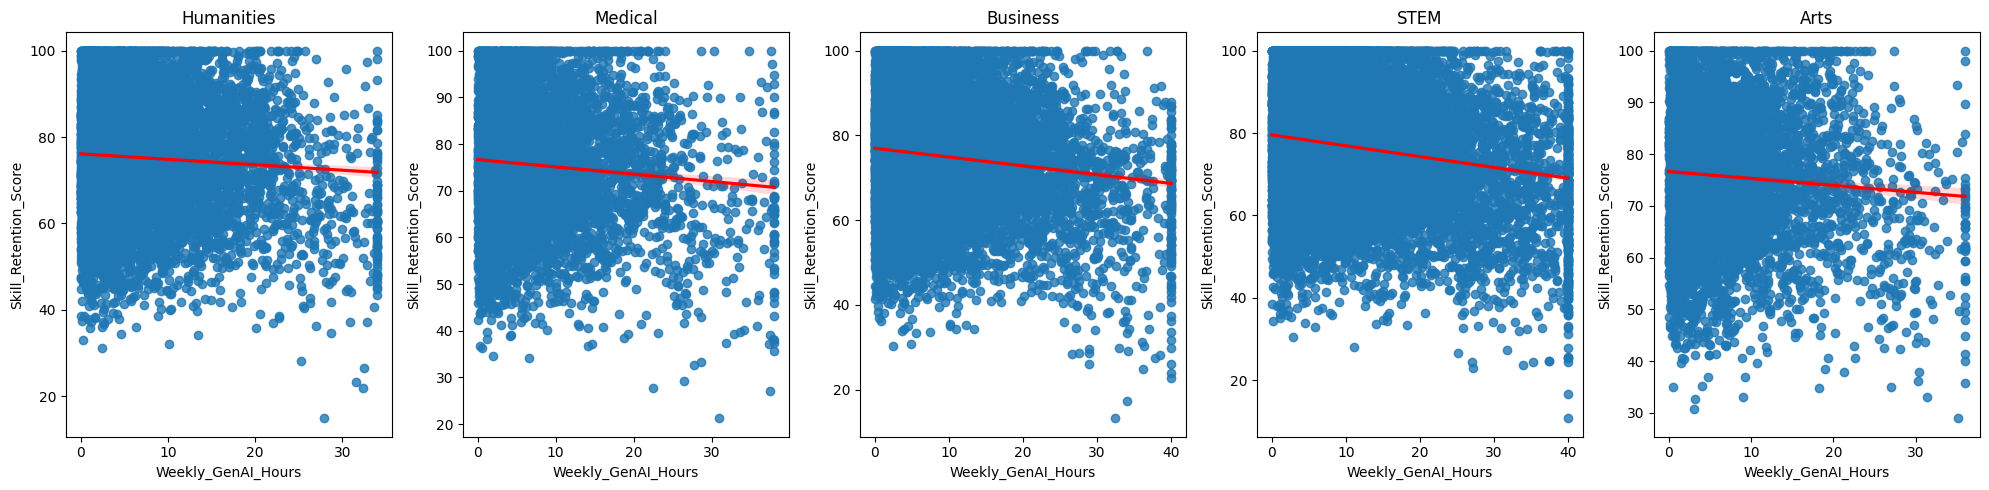

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

Field = df["Major_Category"].unique()

for ax, label in zip(axes, Field):
    data = df[df["Major_Category"] == label]

    sns.regplot(data, x="Weekly_GenAI_Hours", y="Skill_Retention_Score", line_kws={"color":"red"}, ax=ax)
    ax.set_title(f"{label}")
    plt.tight_layout()


## 8. Visualising prompt engineering skills impact on Post semester gpa with AI weekly usage
Assessing whether the Prompt engineering skill has a positive impact on the Grade Point Average

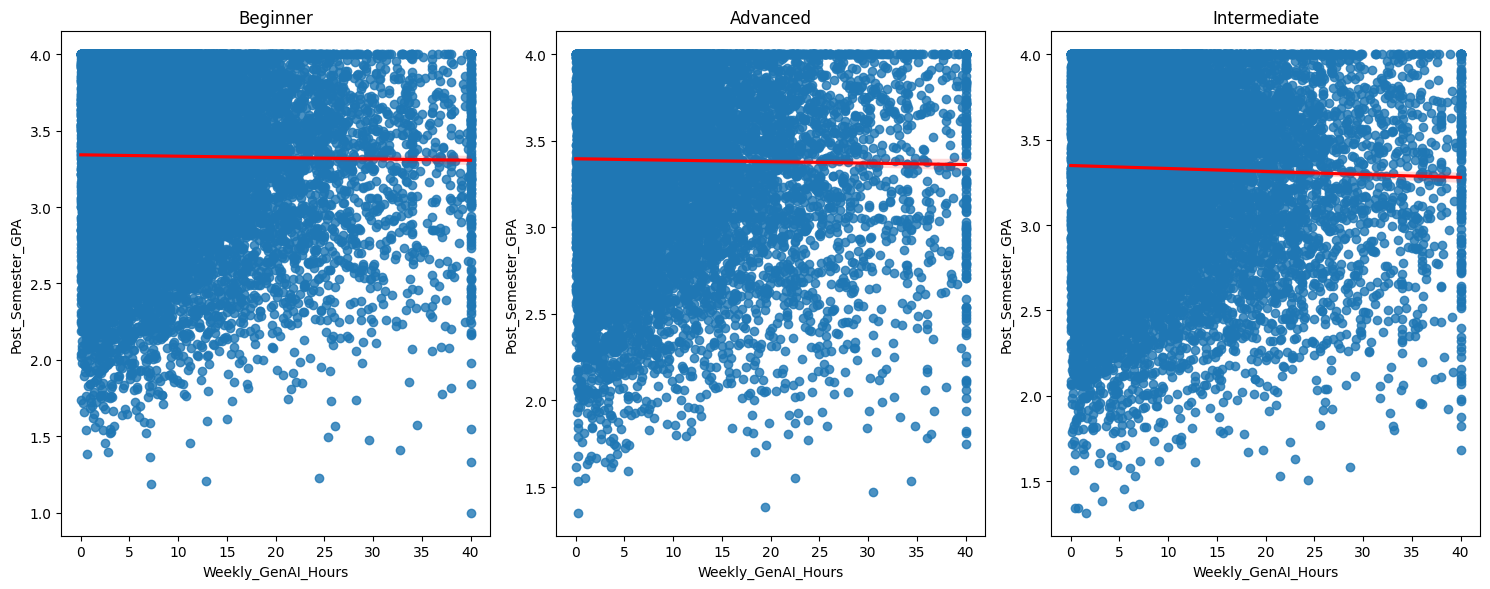

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

Skills = df["Prompt_Engineering_Skill"].unique()

for ax, label in zip(axes, Skills):
    dt = df[df["Prompt_Engineering_Skill"] == label]
    
    sns.regplot(dt, x="Weekly_GenAI_Hours", y="Post_Semester_GPA", line_kws={"color":"red"}, ax=ax)
    ax.set_title(f"{label}")
    plt.tight_layout()

## 9. Does AI dependency affect traditional study hours?

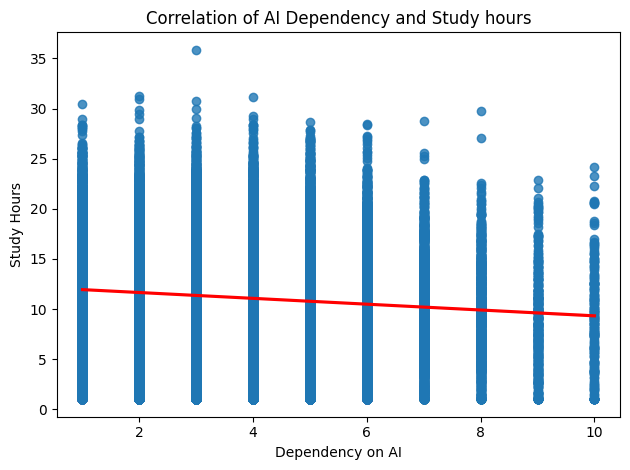

In [64]:
#Computing the correlation between AI dependency and Traditional study hours
fig, ax = plt.subplots()

sns.regplot(df, x="Perceived_AI_Dependency", y="Traditional_Study_Hours", line_kws={"color":"red"}, ax=ax)
ax.set_title("Correlation of AI Dependency and Study hours")
ax.set_ylabel("Study Hours")
ax.set_xlabel("Dependency on AI")

plt.tight_layout()
plt.show()

In [60]:
#Impact of AI dependency on the traditional study hours — Correlation between AI dependency and Traditional study hours
correl = df["Perceived_AI_Dependency"].corr(df["Traditional_Study_Hours"], method='spearman')
print(f"There seems to be a weak negative correlation, {correl.round(1)}, between AI dependency and Weekly study hours, which we can conclude that as AI dependency grows greater, the hours of studying that a student chooses to undertake decrease. Highlighting that there might be a negative impact posed by AI usage on \nstudents academic performances")

There seems to be a weak negative correlation, -0.1, between AI dependency and Weekly study hours, which we can conclude that as AI dependency grows greater, the hours of studying that a student chooses to undertake decrease. Highlighting that there might be a negative impact posed by AI usage on 
students academic performances


## 10. Scatter plot of Burnout risk level and AI usage
Turn burnout risk level to 1, 2, 3 and create a scatter plot to analyse the relationship between AI usage and burnout risk 

In [7]:
#Duplicate a column and add it onto the existing dataframe
df["Burnout_Level"] = df["Burnout_Risk_Level"].reset_index(drop=True)

#1. Mapping and converting the 'High, Medium, Low' levels to numerical values
mapping = {'High' : 3, "Medium" : 2, "Low" : 1}

#2. Apply mapping to column
df["Burnout_Level"] = df["Burnout_Level"].map(mapping)
#df["Burnout_Level"] 

In [32]:
#Checking whether the duplication and mapping methods were successful.
print(f"{df.info()}")
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  str    
 2   Year_of_Study               50000 non-null  str    
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  str    
 6   Prompt_Engineering_Skill    50000 non-null  str    
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  str    
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           50000 non-null

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level,Burnout_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High,3
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low,1
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium,2
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium,2
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium,2


In [79]:
#Correlation between AI dependency and Burnout levels

corr_ai_burnout = df["Perceived_AI_Dependency"].corr(df["Burnout_Level"], method='spearman')
corr_ai_burnout

print(f"There seems to be a positive, although not strong, Spearman correlation: {corr_ai_burnout.round(2)}, relationship between AI dependency and Burnout levels. This tells us that the more AI is used, the higher the possibility of burnout.")

There seems to be a positive, although not strong, Spearman correlation: 0.34, relationship between AI dependency and Burnout levels. This tells us that the more AI is used, the higher the possibility of burnout.


In [80]:
#Correlation between AI dependency and Anxiety levels during exams

corr_ai_anxiety = df["Perceived_AI_Dependency"].corr(df["Anxiety_Level_During_Exams"], method='spearman')
corr_ai_anxiety.round(2)
print(f"There seems to be a weak positive, Spearman correlation: {corr_ai_anxiety.round(2)}, relationship between AI dependency and anxiety levels during exams. This tells us that the more AI is used, the higher the anxiety levels during exams.")

There seems to be a weak positive, Spearman correlation: 0.28, relationship between AI dependency and anxiety levels during exams. This tells us that the more AI is used, the higher the anxiety levels during exams.


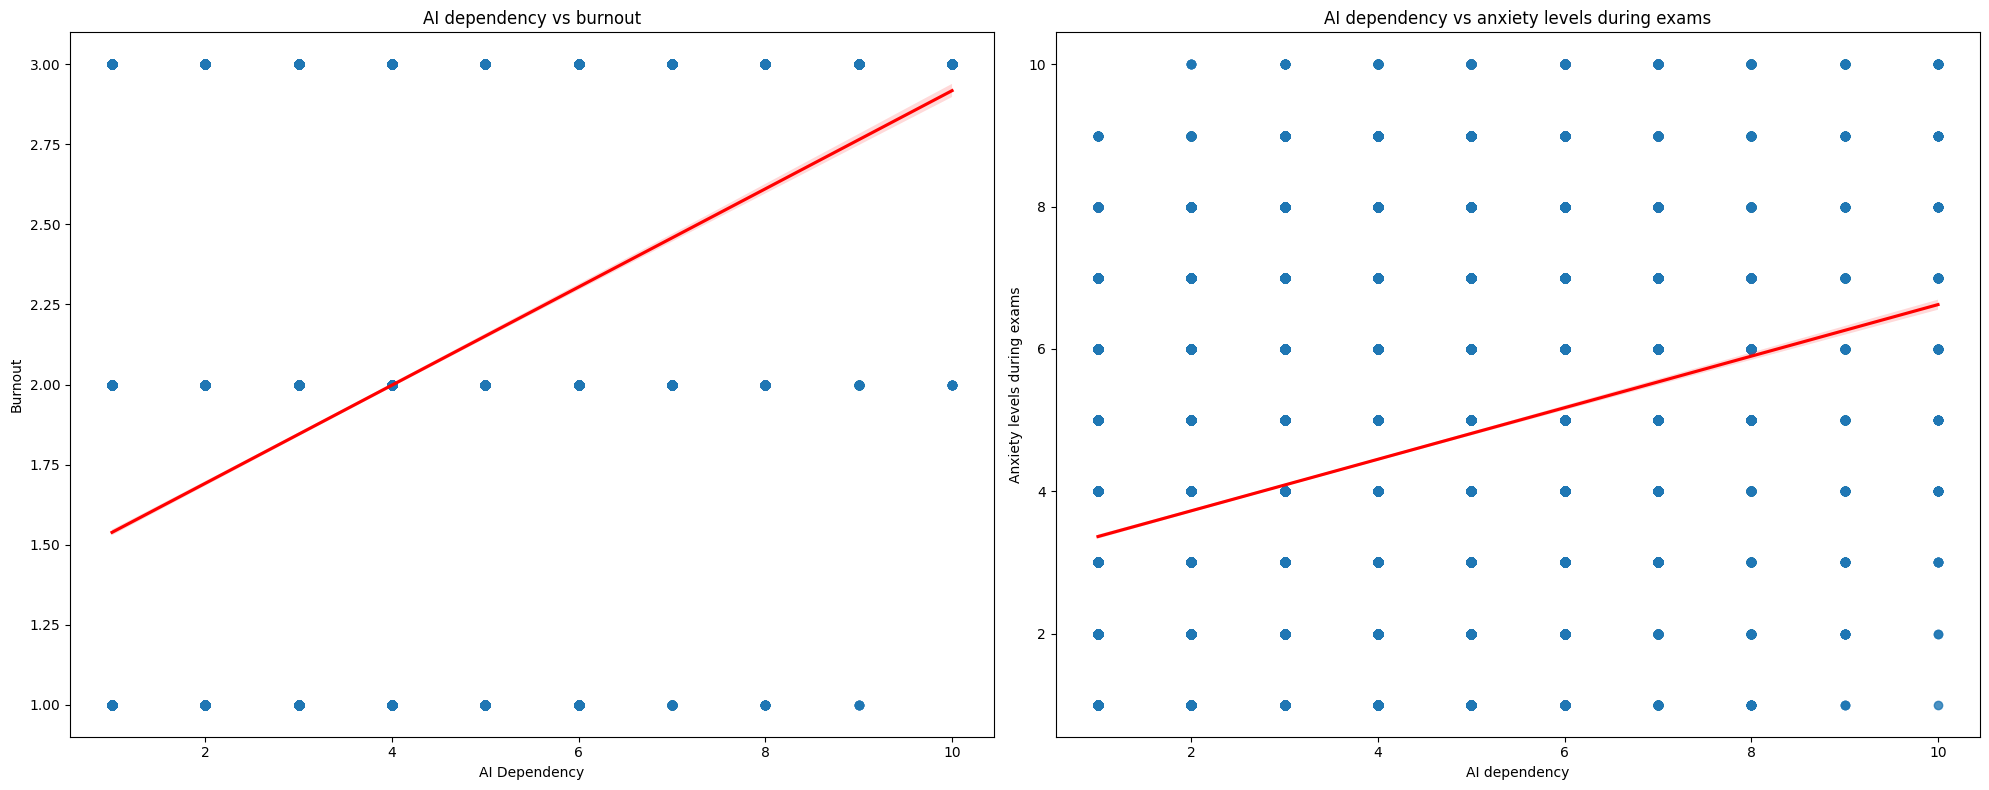

As stated previously, the higher the AI dependency, the greater the risk of burnout and anxiety levels during exam time.


In [15]:
#Computing the relationship between AI dependency and burnout risk levels
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

#first visualisation
sns.regplot(x=df["Perceived_AI_Dependency"], y=df["Burnout_Level"], line_kws={"color":"red"}, ax=axes[0])
axes[0].set_title("AI dependency vs burnout")
axes[0].set_xlabel("AI Dependency")
axes[0].set_ylabel("Burnout")

#second visualisation
sns.regplot(x=df["Perceived_AI_Dependency"], y=df["Anxiety_Level_During_Exams"], line_kws={"color":"red"}, ax=axes[1])
axes[1].set_title("AI dependency vs anxiety levels during exams")
axes[1].set_xlabel("AI dependency")
axes[1].set_ylabel("Anxiety levels during exams")

#displaying the visualisations
plt.tight_layout()
plt.show()

print("As stated previously, a higher the AI dependency is associated with a greater the risk of burnout and anxiety levels during exam time.")

## 11. Consolidating correlation findings through visualisation

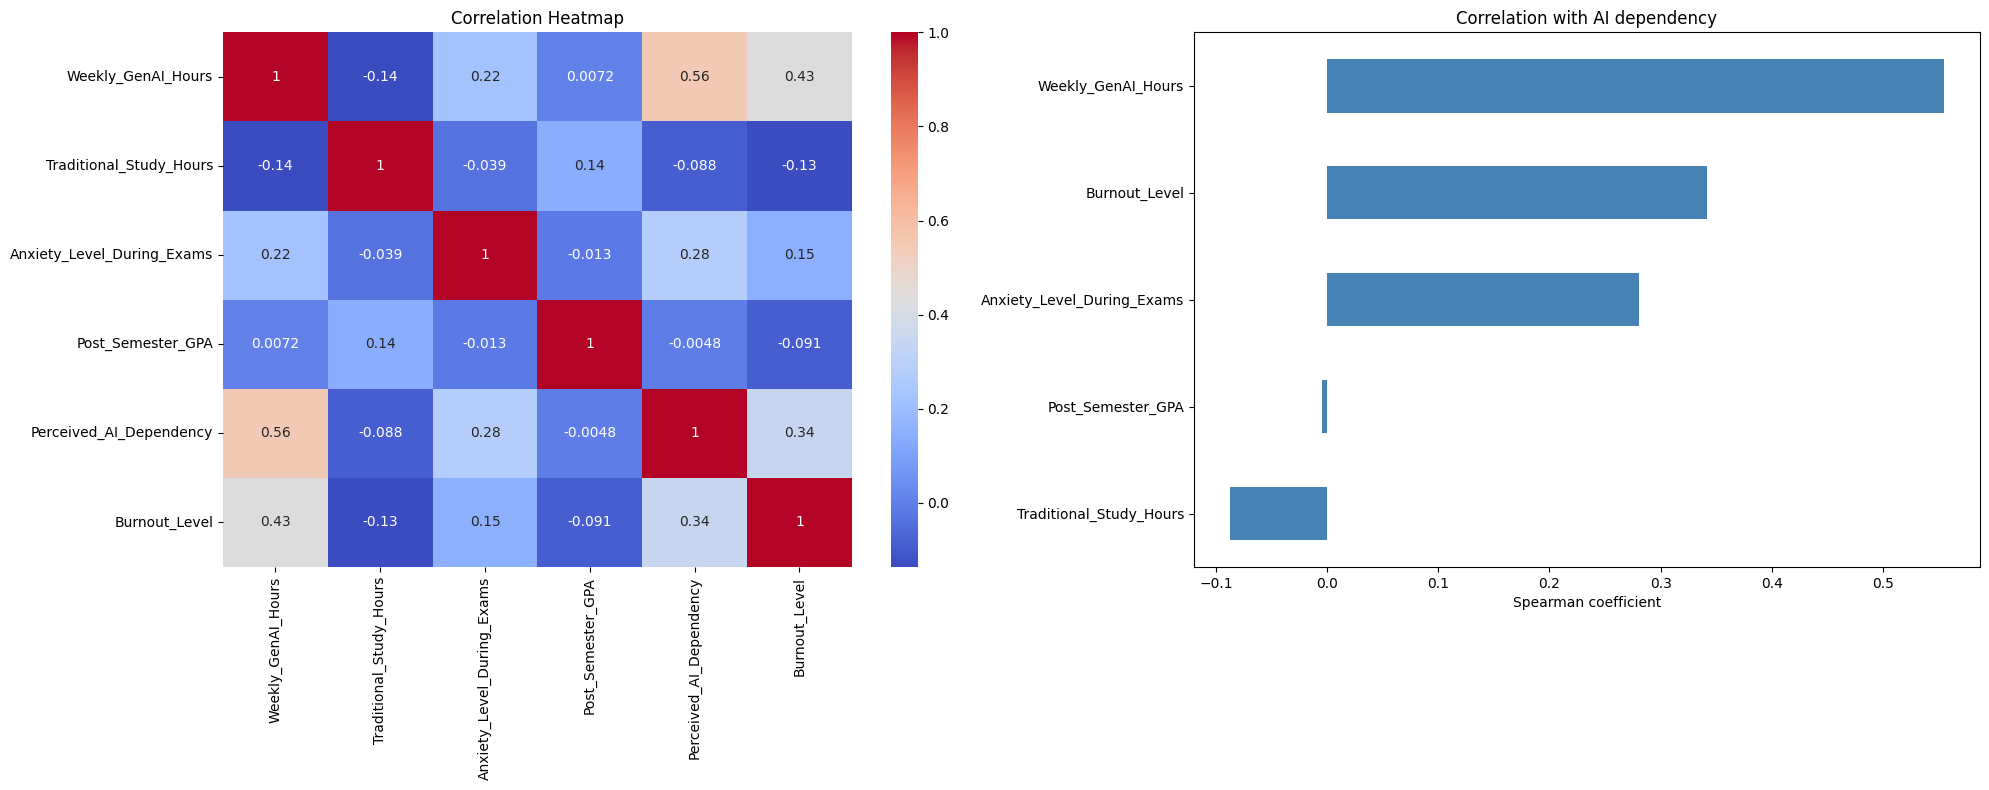

In [65]:
#Conglomeration of the above computed data into one whole, simple, visual to show correlation.

#Drawing the canvas
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

#Correlation matrix computation
num_cols = ["Weekly_GenAI_Hours", "Traditional_Study_Hours", "Anxiety_Level_During_Exams", "Post_Semester_GPA", "Perceived_AI_Dependency", "Burnout_Level"]
corr = df[num_cols].corr(method='spearman')

#First visualisation
sns.heatmap(corr, annot=True, cmap='coolwarm', ax=axes[0])
axes[0].set_title("Correlation Heatmap")

#Second visualisation
corr["Perceived_AI_Dependency"].drop("Perceived_AI_Dependency").sort_values().plot(kind='barh', color='steelblue', ax=axes[1])
axes[1].set_title("Correlation with AI dependency")
axes[1].set_xlabel("Spearman coefficient")

#Showing the visualisations
plt.tight_layout()
plt.show()

## 12. Multiple regression

In [73]:
import statsmodels.formula.api as smf

model = smf.ols(
    "Post_Semester_GPA ~ Weekly_GenAI_Hours + Traditional_Study_Hours"
    "+C(Major_Category) + C(Year_of_Study)", data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      Post_Semester_GPA   R-squared:                       0.027
Model:                            OLS   Adj. R-squared:                  0.027
Method:                 Least Squares   F-statistic:                     141.1
Date:                Sat, 18 Jul 2026   Prob (F-statistic):          5.88e-293
Time:                        15:32:14   Log-Likelihood:                -35158.
No. Observations:               50000   AIC:                         7.034e+04
Df Residuals:                   49989   BIC:                         7.044e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

## 13. Summary of key findings.

It seems AI dependency does have a correlation with how much generative AI is used within a week by students. Furthermore, there seems to be a positive relationship between AI Dependecy and anxiety-levels spiking during exams. While correlation alone cannot establish that AI causes burnout and anxiety, considering that moderate correlations were presented as well, AI is associated with burnouts and academic anxiety. 

In [62]:
summary = pd.DataFrame({
    'Finding': [
        'Dataset size',
        'GPA growth pct (+)',
        'Impact of AI on study hours',
        'Burnout due to AI dependency',
        'Burnout due to weekly AI use'
    ],
    'Value': [
    f"{len(df)} rows",
    f"{GPA_growth_pct.round(2)}",
    f"{df["Perceived_AI_Dependency"].corr(df["Traditional_Study_Hours"], method='spearman').round(2)}",
    f"{df["Perceived_AI_Dependency"].corr(df["Burnout_Level"], method='spearman').round(2)}",
    f"{df["Weekly_GenAI_Hours"].corr(df["Burnout_Level"], method='spearman').round(2)}"
    ]})

summary

,Finding,Value
0,Dataset size,50000 rows
1,GPA growth pct (+),6.46
2,Impact of AI on study hours,-0.09
3,Burnout due to AI dependency,0.34
4,Burnout due to weekly AI use,0.43


In [27]:
# saving the dataset as a csv file
df.to_csv("./ai_impact_on_students.csv", index=False)